## Correlation Analysis
: 변수들 간 상관관계 분석 -> 어떤 두 변수가 상호작용을 통해 stroke에 영향을 미치는지 알 수 있음

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
data = pd.read_csv('원본데이터-이진화.csv')
data = data.drop(['Unnamed: 0','stroke'],axis=1)# 필요없는 Unnamed컬럼과 target 변수인 stroke 컬럼 삭제 
data.head()

,gender,age,hypertension,heart_disease,ever_married,Residence_type,avg_glucose_level,bmi,Govt_job,Never_worked,Private,Self-employed,children,formerly smoked,never smoked,smokes
0,1,67,0,1,1,1,228.69,36.6,0,0,1,0,0,1,0,0
1,1,80,0,1,1,0,105.92,32.5,0,0,1,0,0,0,1,0
2,0,49,0,0,1,1,171.23,34.4,0,0,1,0,0,0,0,1
3,0,79,1,0,1,0,174.12,24.0,0,0,0,1,0,0,1,0
4,1,81,0,0,1,1,186.21,29.0,0,0,1,0,0,1,0,0


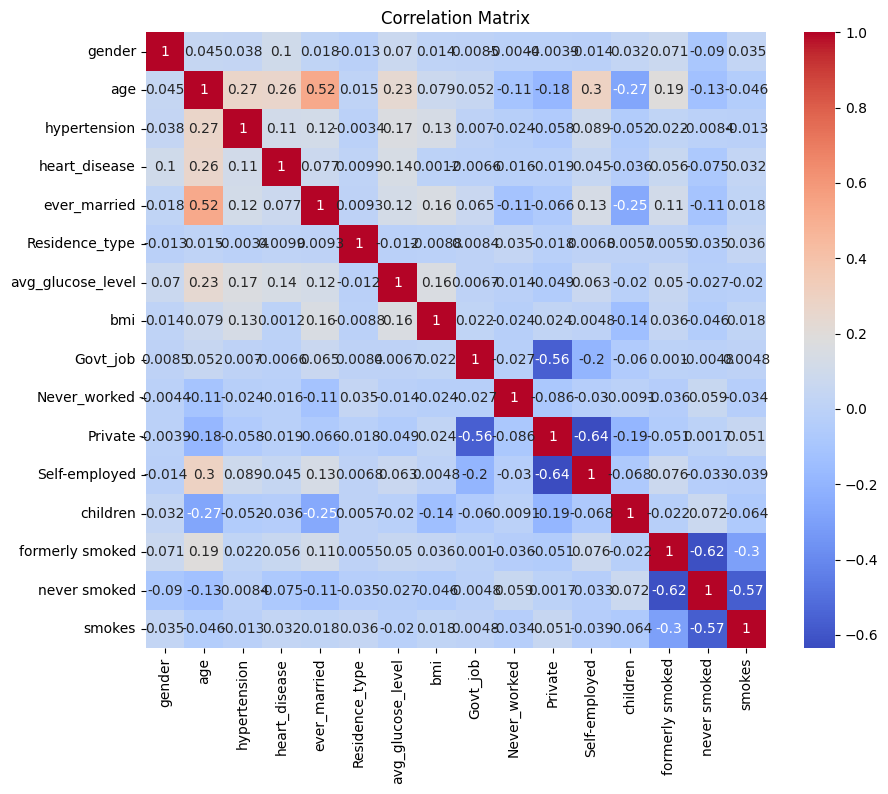

In [19]:
# 인코딩된 원본데이터 상관관계 계산
correlation_matrix = data.corr()

# 상관관계 히트맵 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [20]:
# correlation_matrix에서 일정 기준 넘는 컬럼 쌍 출력
# threshold: 상관계수의 절대값이 threshold보다 큰 경우 출력

def get_high_correlation_pairs(correlation_matrix, threshold):
    pairs = []
    cols = correlation_matrix.columns

    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            if abs(correlation_matrix.iloc[i, j]) >= threshold:
                pair = (cols[i], cols[j], correlation_matrix.iloc[i, j])
                pairs.append(pair)

    return pairs

# 높은 상관관계를 가지는 컬럼 쌍 출력 (절대값이 0.5 이상인 경우)
high_correlation_pairs = get_high_correlation_pairs(correlation_matrix, 0.5)

# 결과 출력
for pair in high_correlation_pairs:
    print(f"Column 1: {pair[0]}, Column 2: {pair[1]}, Correlation: {pair[2]}")

Column 1: age, Column 2: ever_married, Correlation: 0.5230174752915481
Column 1: Govt_job, Column 2: Private, Correlation: -0.563123631415379
Column 1: Private, Column 2: Self-employed, Correlation: -0.6356236315240307
Column 1: formerly smoked, Column 2: never smoked, Correlation: -0.6165854091170861
Column 1: never smoked, Column 2: smokes, Correlation: -0.5681660004458241


## Interaction Effects (OLS 회귀분석)
: 변수들 간의 상호작용 효과 파악 -> correlation analysis에서 상호작용을 확인한 두 변수가 뇌졸중 발생에 어떤 영향을 끼치는지 확인

* 다중공선성 처리를 해야 의미있는 정보를 얻을 수 있음(상관계수 행렬 분석, 분산팽창계수 VIF 계산,공선성 행렬, 변수중요도 확인)

In [21]:
# age와 ever married
import statsmodels.api as sm
import pandas as pd

# 데이터 새로 불러오기
data = pd.read_csv('원본데이터-이진화.csv')

# 상호작용 항목을 생성합니다.
data['age_married_interaction'] = data['age'] * data['ever_married']

# 회귀 모델을 적합합니다.
model = sm.OLS(data['stroke'], sm.add_constant(data[['age', 'ever_married', 'age_married_interaction']]))
results = model.fit()

# 회귀 결과를 출력합니다.
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                 stroke   R-squared:                       0.063
Model:                            OLS   Adj. R-squared:                  0.063
Method:                 Least Squares   F-statistic:                     77.15
Date:                Sun, 21 May 2023   Prob (F-statistic):           2.76e-48
Time:                        09:36:35   Log-Likelihood:                 389.55
No. Observations:                3425   AIC:                            -771.1
Df Residuals:                    3421   BIC:                            -746.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

* age와 ever_married의 상호작용의 영향력은 통계적으로 유의미하지 않음 (p-value가 0.05보다 큼)
* 지금은 당연한 결과만 나와서 이 과정이 의미 있는지 모르겠음 -> feature selection 과정 필요

In [22]:
# Govt_job과  Private
# 상호작용 항목을 생성합니다.
data['Govt_Private_interaction'] = data['Private'] * data['Govt_job']

# 회귀 모델을 적합합니다.
model = sm.OLS(data['stroke'], sm.add_constant(data[['Private', 'Govt_job', 'Govt_Private_interaction']]))
results = model.fit()

# 회귀 결과를 출력합니다.
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                 stroke   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     2.112
Date:                Sun, 21 May 2023   Prob (F-statistic):              0.121
Time:                        09:36:35   Log-Likelihood:                 279.55
No. Observations:                3425   AIC:                            -553.1
Df Residuals:                    3422   BIC:                            -534.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                   

/usr/local/lib/python3.10/dist-packages/statsmodels/regression/linear_model.py:1934: RuntimeWarning: divide by zero encountered in double_scalars
  return np.sqrt(eigvals[0]/eigvals[-1])


* 가장 작은 eigenvalue가 0. 다중공선성 평가 및 처리 필요

In [23]:
# Private,  Self-employed
# 상호작용 항목을 생성합니다.
data['Private_Selfemployed_interaction'] = data['Private'] * data['Self-employed']

# 회귀 모델을 적합합니다.
model = sm.OLS(data['stroke'], sm.add_constant(data[['Private', 'Self-employed', 'Private_Selfemployed_interaction']]))
results = model.fit()

# 회귀 결과를 출력합니다.
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                 stroke   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.002
Method:                 Least Squares   F-statistic:                     4.942
Date:                Sun, 21 May 2023   Prob (F-statistic):            0.00719
Time:                        09:36:36   Log-Likelihood:                 282.38
No. Observations:                3425   AIC:                            -558.8
Df Residuals:                    3422   BIC:                            -540.3
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                       coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const   

/usr/local/lib/python3.10/dist-packages/statsmodels/regression/linear_model.py:1934: RuntimeWarning: divide by zero encountered in double_scalars
  return np.sqrt(eigvals[0]/eigvals[-1])


가장 작은 eigenvalue가 0. 다중공선성 평가 및 처리 필요

In [24]:
# formerly smoked, never smoked
# 상호작용 항목을 생성합니다.
data['formerly_never_smoked_interaction'] = data['formerly smoked'] * data['never smoked']

# 회귀 모델을 적합합니다.
model = sm.OLS(data['stroke'], sm.add_constant(data[['formerly smoked', 'never smoked', 'formerly_never_smoked_interaction']]))
results = model.fit()

# 회귀 결과를 출력합니다.
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                 stroke   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     3.017
Date:                Sun, 21 May 2023   Prob (F-statistic):             0.0491
Time:                        09:36:36   Log-Likelihood:                 280.46
No. Observations:                3425   AIC:                            -554.9
Df Residuals:                    3422   BIC:                            -536.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

/usr/local/lib/python3.10/dist-packages/statsmodels/regression/linear_model.py:1934: RuntimeWarning: divide by zero encountered in double_scalars
  return np.sqrt(eigvals[0]/eigvals[-1])


가장 작은 eigenvalue가 0. 다중공선성 평가 및 처리 필요

In [25]:
# never smoked, smokes
# 상호작용 항목을 생성합니다.
data['neversmoked_smokes_interaction'] = data['never smoked'] * data['smokes']

# 회귀 모델을 적합합니다.
model = sm.OLS(data['stroke'], sm.add_constant(data[['never smoked', 'smokes', 'neversmoked_smokes_interaction']]))
results = model.fit()

# 회귀 결과를 출력합니다.
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                 stroke   R-squared:                       0.002
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     3.017
Date:                Sun, 21 May 2023   Prob (F-statistic):             0.0491
Time:                        09:36:36   Log-Likelihood:                 280.46
No. Observations:                3425   AIC:                            -554.9
Df Residuals:                    3422   BIC:                            -536.5
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

/usr/local/lib/python3.10/dist-packages/statsmodels/regression/linear_model.py:1934: RuntimeWarning: divide by zero encountered in double_scalars
  return np.sqrt(eigvals[0]/eigvals[-1])


가장 작은 eigenvalue가 0. 다중공선성 평가 및 처리 필요

## Subgroup Analysis
: 다양한 변수의 조합으로 뇌졸중 발생 확률을 비교 -> 특정 조건의 인구 그룹의 뇌졸중 위험 요인을 파악할 수 있음.
* correlation analysis, interaction effects 분석결과 또는 시각화 분석의 결과를 토대로 group을 나눠서 분석. (가설, subgroup을 근거로 하는 생물학적 근거 설명 필요)
* Overfitting을 방지하기 위해 GridSearchCV로 최적 파라미터(max_depth) 탐색 과정 포함
* 특정 조건을 만족하는 사람에게 뇌졸중에 큰 영향을 끼치는 요인(어떤 요인이 있으면 더 위험한지)과 관련된 실질적인 예방 방법을 제안할 수 있음!!!

male subgroup analysis

In [26]:
# male subgroup analysis
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# 데이터 로드
data = pd.read_csv('원본데이터-이진화.csv')  # 데이터셋을 적절히 로드합니다.

# 'gender'가 1(Male)인 그룹 데이터를 추출하여 X와 y로 나누기
male_data = data[data['gender'] == 1]
male_data = male_data.drop(['gender','Unnamed: 0'], axis=1) # 'gender', 'unnamed:0' 을 제외

X_male = male_data.drop(['stroke'], axis=1)  # 입력 변수
y_male = male_data['stroke']  # 타겟 변수

# 의사결정트리 모델 생성
dt = DecisionTreeClassifier()

# GridSearchCV를 사용하여 최적의 파라미터 탐색
param_grid = {'max_depth': [3, 5, 7]}  # 탐색할 max_depth 값의 후보들
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, scoring='accuracy', cv=5)
grid_search.fit(X_male, y_male)

# 최적의 파라미터 확인
best_max_depth = grid_search.best_params_['max_depth']
print("Best max_depth:", best_max_depth)

# 최적의 파라미터로 의사결정트리 모델 학습
dt_best = DecisionTreeClassifier(max_depth=best_max_depth)
dt_best.fit(X_male, y_male)

Best max_depth: 3


DecisionTreeClassifier(max_depth=3)

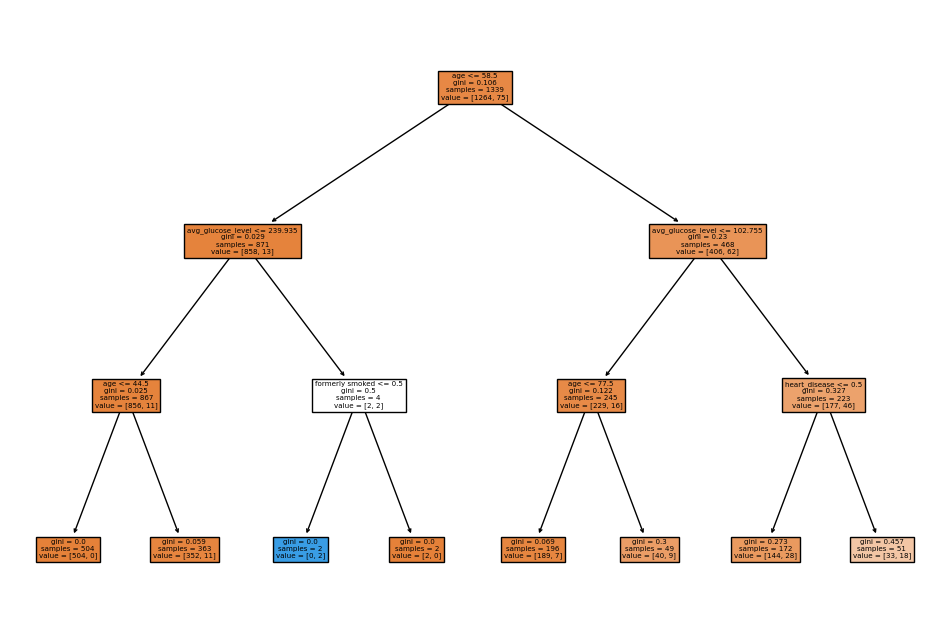

In [27]:
# 의사결정 트리 시각화
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(12, 8))
plot_tree(dt_best, feature_names=X_male.columns, filled=True)
plt.show()

* Gini Impurity (지니 불순도): Gini impurity는 해당 노드에서의 데이터의 혼잡도를 측정하는 지표입니다. 노드의 지니 불순도가 낮을수록 해당 노드의 데이터는 더 순수하게 분류되어 있다고 볼 수 있습니다. 의사결정 트리는 지니 불순도를 최소화하도록 데이터를 분할합니다.
* Value: Value는 해당 노드에서의 각 클래스의 데이터 포인트 수를 나타냅니다. 예를 들어, [0, 5]는 클래스 0이 0개이고 클래스 1이 5개의 데이터를 가지고 있다는 의미입니다.

* 과적합 방지는 모델의 일반화 성능을 향상시키기 위한 요소이므로, 지금 하려는 subgroup analysis의 목적에서는 크게 중요하지 않음.
* 정규화 필요 X
* 분기 기준과 도메인 지식으로 결과를 해석할 수 있음.

In [28]:
# 중요도가 높은 순서대로 변수와 중요도 값 확인
feature_importances = dt_best.feature_importances_
important_features = X_male.columns[np.argsort(feature_importances)[::-1]]

print("Important features:")

for rank, feature in enumerate(important_features, 1):
    importance = feature_importances[np.where(X_male.columns == feature)[0][0]]
    print(f"{rank}. {feature}: {importance}")

Important features:
1. age: 0.4804006555263778
2. avg_glucose_level: 0.2983163795922385
3. heart_disease: 0.12993022418719977
4. formerly smoked: 0.0913527406941841
5. smokes: 0.0
6. never smoked: 0.0
7. children: 0.0
8. Self-employed: 0.0
9. Private: 0.0
10. Never_worked: 0.0
11. Govt_job: 0.0
12. bmi: 0.0
13. Residence_type: 0.0
14. ever_married: 0.0
15. hypertension: 0.0


female subgroup analysis

In [29]:
# 'gender'가 0(Female)인 그룹 데이터를 추출하여 X와 y로 나누기
female_data = data[data['gender'] == 0]
female_data = female_data.drop(['gender','Unnamed: 0'], axis=1) # 'gender', 'unnamed:0' 을 제외

X_female = male_data.drop(['stroke'], axis=1)  # 입력 변수
y_female = male_data['stroke']  # 타겟 변수

# 의사결정트리 모델 생성
dt = DecisionTreeClassifier()

# GridSearchCV를 사용하여 최적의 파라미터 탐색
param_grid = {'max_depth': [3, 5, 7]}  # 탐색할 max_depth 값의 후보들
grid_search = GridSearchCV(estimator=dt, param_grid=param_grid, scoring='accuracy', cv=5)
grid_search.fit(X_male, y_male)

# 최적의 파라미터 확인
best_max_depth = grid_search.best_params_['max_depth']
print("Best max_depth:", best_max_depth)

# 최적의 파라미터로 의사결정트리 모델 학습
dt_best = DecisionTreeClassifier(max_depth=best_max_depth)
dt_best.fit(X_female, y_female)

Best max_depth: 3


DecisionTreeClassifier(max_depth=3)

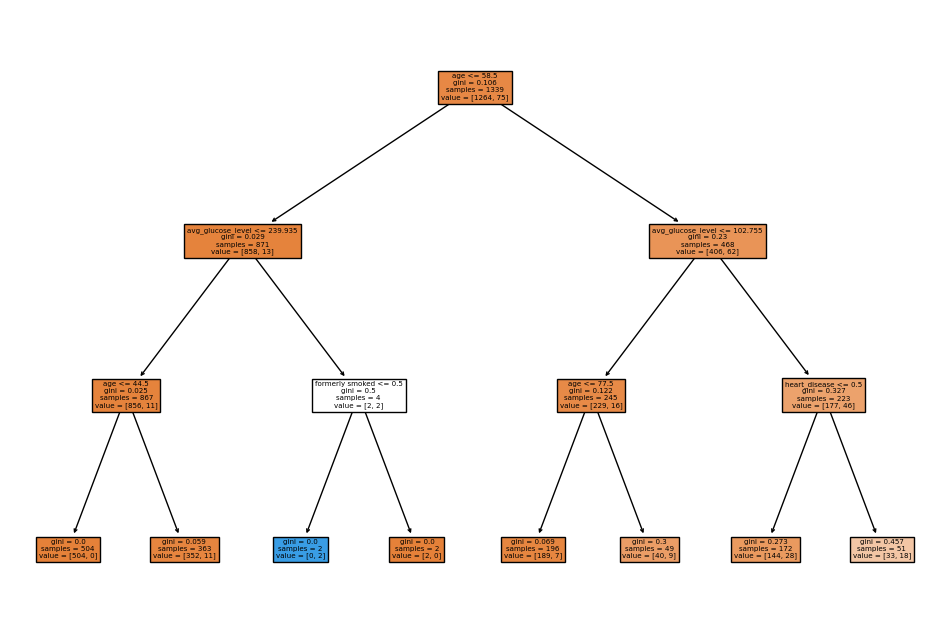

In [30]:
# 의사결정 트리 시각화
plt.figure(figsize=(12, 8))
plot_tree(dt_best, feature_names=X_female.columns, filled=True)
plt.show()

In [31]:
# 중요도가 높은 순서대로 변수와 중요도 값 확인
feature_importances = dt_best.feature_importances_
important_features = X_female.columns[np.argsort(feature_importances)[::-1]]

print("Important features:")

for rank, feature in enumerate(important_features, 1):
    importance = feature_importances[np.where(X_female.columns == feature)[0][0]]
    print(f"{rank}. {feature}: {importance}")

Important features:
1. age: 0.4804006555263778
2. avg_glucose_level: 0.2983163795922385
3. heart_disease: 0.12993022418719977
4. formerly smoked: 0.0913527406941841
5. smokes: 0.0
6. never smoked: 0.0
7. children: 0.0
8. Self-employed: 0.0
9. Private: 0.0
10. Never_worked: 0.0
11. Govt_job: 0.0
12. bmi: 0.0
13. Residence_type: 0.0
14. ever_married: 0.0
15. hypertension: 0.0


male에서는 age, avg_glucose_level, heart_disease, formerly smoked가 중요한 feature이고, female에서는 age, ave_glucose_level, heart_disease, Residence_type이 중요한 feature로 계산됨.
=> 더 세세하게 조건을 나눠 중요한 feature를 알아내고 해당 집단에게 뇌졸중 발병 예방에 가장 효과적인 예방방법을 제안할 수 있음
* 이는 한정된 데이터와 통계적 분석에 기반한 내용이므로 인구 전체에 적용되지 않을 수 있음. 추가적인 연구와 검증이 필요. 
* 조기 식별, 위험 평가 및 개인화된 권장 사항을 지원하여 궁극적으로 더 나은 건강 결과 위한 사전 예방적 뇌졸중 예방을 촉진할 수 있는 보완 도구 역할.
의료적 진단 방법과는 별개의 보조적 보완 도구로 사용이 가능함.